In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression


## Exercice 4 : impact et detection d'outliers



b_0=6.375493772129367 et b_1=5.294392189688226


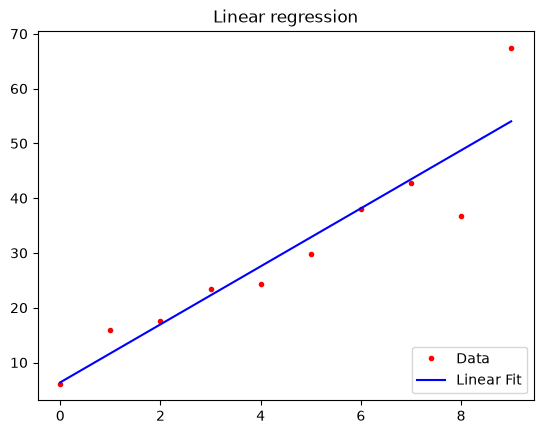

In [2]:
#generation de donnees test
def generate_data(n_samples, outlier=False, b_1=4.):
    x = np.arange(n_samples)
    y = 10. + b_1*x + np.random.randn(n_samples)*3.
    if outlier:
        y[-1] += 20
    return x, y

def s2(y_true, y_pred):
    n = len(y_true)
    SSE = np.sum((y_true - y_pred)**2)
    return SSE / (n-1)


x, y = generate_data(n_samples=10, outlier=True)
# instanciation de sklearn.linear_model.LinearRegression
lr = LinearRegression()
lr.fit(x[:, np.newaxis], y)  # np.newaxis est utilise car x doit etre une matrice 2d avec 'LinearRegression'

# representation du resultat

print('b_0='+str(lr.intercept_)+' et b_1='+str(lr.coef_[0]))

fig = plt.figure()
plt.plot(x, y, 'r.')
plt.plot(x, lr.predict(x[:, np.newaxis]), 'b-')
plt.legend(('Data', 'Linear Fit'), loc='lower right')
plt.title('Linear regression')
plt.show()


### <span style="color:blue">QUESTION 4.1 :</span> 


Remarquons que la ligne 'y[9]=y[9]+20' génere artificiellement une donnée aberrante.

Tester l'impact de la donnée aberrante en estimant b_0, b_1 et s^2 sur 
- 5 jeux de données générés comme dans la cellule précédente et
- 5 autres jeux aussi générés suivant cette méthode, mais sans la données aberrant (simplement ne pas executer la ligne y[9]=y[9]+20).

On remarque que $\beta_0 = 10$, $\beta_1 = 4$ et $\sigma=3$ dans les données simulees.


### <span style="color:blue">REPONSE 4.1 :</span> 



b_0=5.9965359715061375 et b_1=5.195729973636407
sigma : 27.635647647053556
b_0=7.539179835872229 et b_1=4.851318464634946
sigma : 33.4414904261678
b_0=6.791378659577898 et b_1=4.916144415006921
sigma : 44.28111290743846
b_0=7.419874246417603 et b_1=5.333949924179273
sigma : 39.41587413070933
b_0=5.3729431202003894 et b_1=5.418306179660484
sigma : 30.245847814152146
b_0=9.151673919158586 et b_1=4.244607078729205
sigma : 4.332652638899912
b_0=10.165763099311874 et b_1=3.7518721800168287
sigma : 3.0619704784756614
b_0=11.825991696162205 et b_1=3.6176007660693514
sigma : 5.718554291811438
b_0=5.931354729126571 et b_1=4.323706527583045
sigma : 4.251185267489684
b_0=7.843879201028045 et b_1=4.390919709452488
sigma : 5.4036317527767785


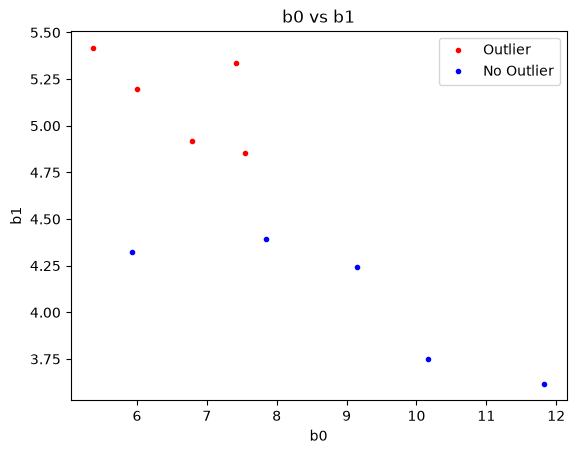

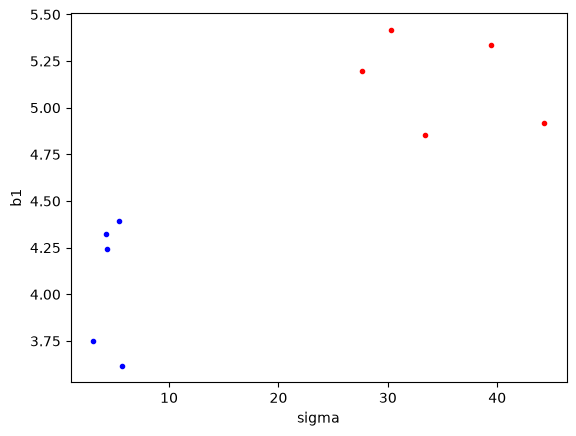

In [27]:
b0_outlier = []
b1_outlier = []
b0_no_outlier = []
b1_no_outlier = []
sigma_outlier = []
sigma_no_outlier = []
for i in range(5):
    x, y = generate_data(n_samples=10, outlier=True)
    # instanciation de sklearn.linear_model.LinearRegression
    lr = LinearRegression()
    lr.fit(x[:, np.newaxis], y)  # np.newaxis est utilise car x doit etre une matrice 2d avec 'LinearRegression'

    # representation du resultat

    print('b_0='+str(lr.intercept_)+' et b_1='+str(lr.coef_[0]))
    print("sigma :", s2(y, lr.predict(x[:, np.newaxis])))
    b0_outlier.append(lr.intercept_)
    b1_outlier.append(lr.coef_[0])
    sigma_outlier.append(s2(y, lr.predict(x[:, np.newaxis])))
for i in range(5):
    x, y = generate_data(n_samples=10, outlier=False)
    # instanciation de sklearn.linear_model.LinearRegression
    lr = LinearRegression()
    lr.fit(x[:, np.newaxis], y)  # np.newaxis est utilise car x doit etre une matrice 2d avec 'LinearRegression'

    # representation du resultat

    print('b_0='+str(lr.intercept_)+' et b_1='+str(lr.coef_[0]))
    print("sigma :", s2(y, lr.predict(x[:, np.newaxis])))
    b0_no_outlier.append(lr.intercept_)
    b1_no_outlier.append(lr.coef_[0])
    sigma_no_outlier.append(s2(y, lr.predict(x[:, np.newaxis])))
plt.figure()
plt.plot(b0_outlier, b1_outlier, 'r.', label='Outlier')
plt.plot(b0_no_outlier, b1_no_outlier, 'b.', label='No Outlier')
plt.xlabel('b0')
plt.ylabel('b1')
plt.legend()
plt.title('b0 vs b1')
plt.figure()
plt.plot(sigma_outlier, b1_outlier, 'r.', label='Outlier')
plt.plot(sigma_no_outlier, b1_no_outlier, 'b.', label='No Outlier')
plt.xlabel('sigma')
plt.ylabel('b1')    

plt.show()  

La variance estimée du bruit est beaucoup plus grande avec une donnée aberrante.
La donnée aberrante introiduit un biais dans l'estimation des statistiques b_0 et b_1.


### <span style="color:blue">QUESTIONS 4.2 :</span> 

#### <span style="color:blue">QUESTION 4.2.a :</span> 
Pour chaque variable i, calculez les profils des résidus $e_{(i)j}=y_j - \hat{y_{(i)j}}$ pour tous les j, où  \hat{y_{(i)j}} est l'estimation de y_j à partir d'un modele  linéaire appris sans l'observation i.
#### <span style="color:blue">QUESTION 4.2.b :</span> 
En quoi le profil des e_{(i)j} est différent pour i=9 que pour les autres i
#### <span style="color:blue">QUESTION 4.2.c :</span> 
Etendre ces calculs pour définir la distance de Cook de chaque variable i

AIDE : pour enlever un élement 'i' de 'x' ou 'y', utiliser x_del_i=np.delete(x,i) et y_del_i=np.delete(y,i) 


In [8]:
x, y = generate_data(n_samples=10, outlier=True)

#### <span style="color:blue">REPONSE 4.2.a :</span> 


In [19]:
def profil_residuel(x, y, i):
    lr = LinearRegression()
    x_del_i = np.delete(x, i)
    y_del_i = np.delete(y, i)
    lr.fit(x_del_i[:, np.newaxis], y_del_i)
    lr.predict(x_del_i[:, np.newaxis])
    residuals = y - lr.predict(x[:, np.newaxis])
    return residuals

In [20]:
profil_residuel(x, y, 9)

array([-2.26513982,  0.72766131,  1.25896016,  0.25605282,  0.03943772,
       -0.45153639,  2.13528951,  1.11974356, -2.82046888, 15.84050898])

#### <span style="color:blue">REPONSE 4.2.b :</span> 

Le profil résiduel de la donnée aberrante est toujours plus grand que les autres, en particulier lorsqu'on ôte la donnée de la base d'apprentissage.

In [16]:
def cook(x, y, i):
    residuals_squared = np.sum(profil_residuel(x, y, i)**2)
    lr = LinearRegression()
    lr.fit(x[:, np.newaxis], y)
    y_pred = lr.predict(x[:, np.newaxis])
    mse = s2(y,y_pred)

    return residuals_squared / (mse * len(x))

#### <span style="color:blue">REPONSE 4.2.c :</span> 


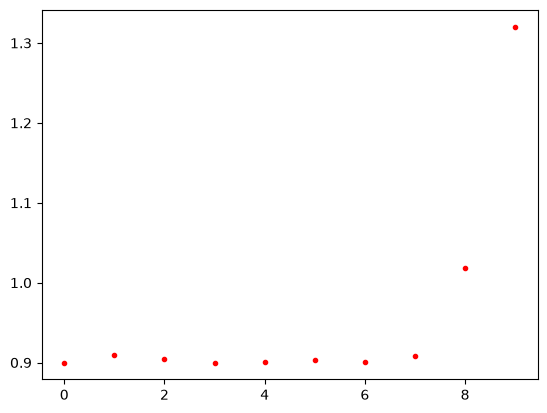

In [21]:
cook(x, y, 9)
cooks =[]
for i in range(len(x)):
    cooks.append(cook(x, y, i))
plt.figure()
plt.plot(cooks, 'r.')
plt.show()

## Question Bonus

Pour un jeu de données de 20 observations obtenues avec un coefficient directeur $\beta_1$ de $0.2$, faire un test d'hypothèse pour vérifier que les données sont corrélées avec une confiance de 95%. 

On rappelle que sous les hypothèses suivantes : 
 * $\mathbb{E}[\epsilon_i] = 0$,
 * $\mathbb{V}[\epsilon_i] = \sigma^2$,
 * $\forall i \neq j, \: Cov(\epsilon_i, \epsilon_j) = 0$,
 
on a : 

* $\mathbb{E}[\hat{\beta_0}] = \beta_0$,
* $\mathbb{E}[\hat{\beta_1}] = \beta_1$,
* $\mathbb{V}[\hat{\beta_0}] = \sigma^2(\frac{1}{n} + \frac{\bar{x_n}^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2})$,
* $\mathbb{V}[\hat{\beta_1}] = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2}$

En faisant l'hypothèse supplémentaire que les erreurs suivent une loi normale, $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, on a :

* $\hat{\beta_1} \sim \mathcal{N}(\beta_1, \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2})$,
* $\frac{(n-2) \cdot s^2}{\sigma^2} \sim \mathcal{X}^2(n-2)$,
* $\hat{\beta_1}$ et $s^2$ indépendants,

où $s^2 = \frac{\sum_{i=1}^n \hat{\epsilon_i}^2}{n-2}$ est un estimateur non biaisé de $\sigma^2$.

On peut en déduire que:

$$ \frac{ \frac{ \hat{\beta_1}-\beta_1}{\sqrt{\frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2}}}}{\sqrt{\frac{\frac{(n-2)s^2}{\sigma^2}}{n-2}}} = \frac{\hat{\beta_1}-\beta_1}{\frac{s}{\sqrt{\sum_{i=1}^n (x_i - \bar{x_n})^2}}} = T_n \sim T(n-2)$$ 

où $T(n-2)$ désigne la loi de Student à $n-2$ degrés de liberté, d'espérance nulle si $n-2 > 1$.

Tester l'hypothèse H_0 : $\beta_1 = 0$ en prenant un risque de 5%. 

In [ ]:
from scipy.stats import t


...